In [13]:
import json
import os

import pandas as pd

# Plot the accuracy

# WITHOUT BEAM MATCHING
dir = '../data/results/experiments/beam_matching_experiment_2'
errors_df = pd.read_csv(os.path.join(dir, 'errors.csv')).drop(columns=['Unnamed: 0'])

control_errors_df = pd.read_csv(os.path.join(dir, 'control.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

control_errors_df

,errors,complexity,runtime
0,4.069309,7762223,73.804273
1,4.268944,7751464,74.563992
2,4.372960,7741831,72.846511
3,4.188052,7657007,76.794310
4,4.196340,7777306,76.673735
5,4.425999,7737611,76.823498
6,4.404599,7692877,41.731926
7,4.228630,7675736,71.170826
8,4.305557,7830108,78.655678
9,4.241132,7708447,78.261559


In [14]:


#
# def make_boxplot(
#         df: pd.DataFrame,
#         control_df: pd.DataFrame,
#         title: str,
#         x_label: str,
#         y_label: str,
#         color: Union[str, dict] = "forestgreen",
#         baseline: float = None,
#         annotate: bool = False,
# ):
#     """
#     Creates a boxplot of the given dataframes.
#
#     :param control_df: DataFrame containing control data
#     :param baseline: Optional baseline value to plot
#     :param df: DataFrame containing experimental data
#     :param title: Plot title
#     :param x_label: X-axis label
#     :param y_label: Y-axis label
#     :param color: Color of the boxes
#     :param annotate: Whether to annotate mean values
#     """
#     # Prepare data by pairing control and regular columns
#     data_values = []
#     labels = []
#     means = []
#     positions = []
#
#     # Calculate positions for paired boxes
#     for i in range(len(df.columns)):
#         base_pos = i * 3  # Leave more space between pairs
#         positions.extend([base_pos, base_pos + 1])  # Positions for control and regular
#
#         # Add control column
#         data_values.append(control_df[df.columns[i]])
#         labels.append(str(i))  # Just the number
#         means.append(control_df[df.columns[i]].mean())
#
#         # Add regular column
#         data_values.append(df[df.columns[i]])
#         labels.append(str(i))  # Same number for the pair
#         means.append(df[df.columns[i]].mean())
#
#     num_boxes = len(data_values)
#
#     plt.figure(figsize=(20, 12))
#     median_props = dict(color="black", linewidth="3")
#     plot = plt.boxplot(
#         data_values,
#         positions=positions,  # Use custom positions
#         patch_artist=True,
#         medianprops=median_props,
#     )
#
#     # Handle color and hatch assignment
#     legend_elements = []
#     for i, patch in enumerate(plot["boxes"]):
#         if i % 2 == 0:  # Control boxes
#             patch.set_facecolor("lightblue")
#             patch.set_hatch('/')
#             if i == 0:  # Only add to legend once
#                 legend_elements.append(patch)
#         else:  # Regular boxes
#             patch.set_facecolor(color if isinstance(color, str) else color.get(labels[i], "forestgreen"))
#             patch.set_hatch('\\')
#             if i == 1:  # Only add to legend once
#                 legend_elements.append(patch)
#
#     # Add legend
#     plt.legend(legend_elements, ['Without beam matching', 'With beam matching'], loc='upper right')
#
#     if baseline:
#         plt.axhline(
#             y=baseline,
#             color="red",
#             linestyle="-",
#             linewidth=2,
#             label="Baseline",
#         )
#
#     if annotate:
#         text_offset = 0.22 if num_boxes < 4 else 0.4
#         for i, mean in enumerate(means, 1):
#             plt.text(
#                 i + text_offset,
#                 mean,
#                 f"\n{mean:.2f}",
#                 horizontalalignment="right",
#                 verticalalignment="center",
#                 color="black",
#             )
#
#     # formatting the plot
#     plt.title(title)
#     plt.grid(axis="y")
#     plt.xlabel(x_label)
#     plt.ylabel(y_label)
#     plt.margins(x=0.1)
#
#     # Set x-ticks at the center of each pair
#     tick_positions = [pos + 0.5 for pos in positions[::2]]  # Center between each pair
#     plt.xticks(tick_positions, [str(i) for i in range(len(df.columns))])
#
#     # Show the plot
#     plt.show()
#



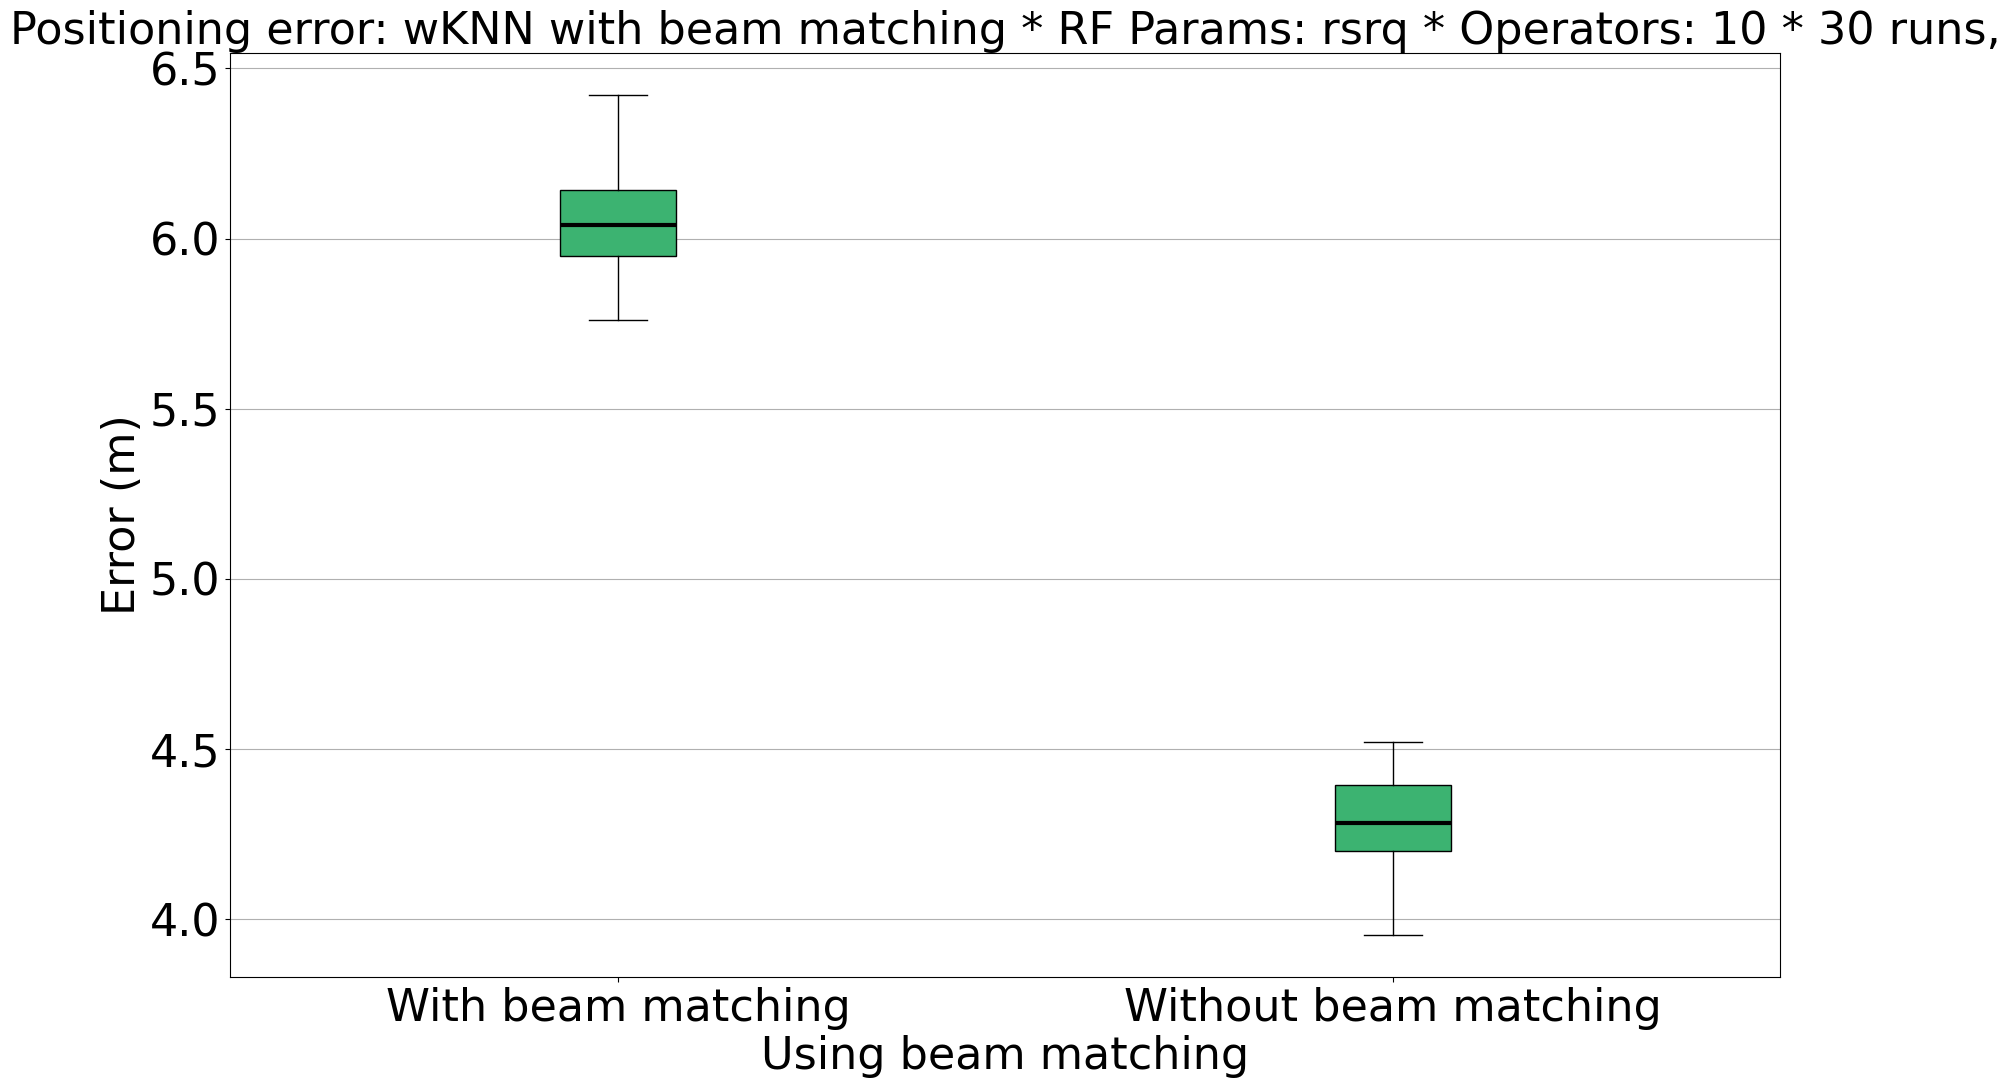

,With beam matching,Without beam matching
0,5.760847,4.069309
1,6.422671,4.268944
2,6.248222,4.372960
3,6.107208,4.188052
4,5.959623,4.196340
5,6.296804,4.425999
6,6.200537,4.404599
7,6.086334,4.228630
8,6.266164,4.305557
9,5.804455,4.241132


In [15]:

from scripts.plotting import make_boxplot
from scripts.utils import operators_to_str

param_str = f'RF Params: {config["rf_param"]}'
operator_str = f'Operators: {operators_to_str(config["operator_choice"])}'

title_string = f'wKNN with beam matching * {param_str} * {operator_str} * {config["n_runs"]} runs,'

df = pd.concat([errors_df['errors'], control_errors_df['errors']], axis=1, ignore_index=True)
df.rename({0: 'With beam matching', 1: 'Without beam matching'}, axis=1, inplace=True)

make_boxplot(
    df=df,
    title=f'Positioning error: {title_string}',
    x_label='Using beam matching',
    y_label='Error (m)',
    color='mediumseagreen',
)
df